In [10]:
# This file takes the source averaged images, source segs and labeled points
# to a new target directory (assuming that the target directory have completed the registration)
# requirement:
# source dir subfolder 
# /Python_post_processing/session/
# image_registration_extras_slice_00.npz
# image_registration_reference_slice_00.npz
# manual_lv_segmentation_slice_000.npz

# target dir subfolder 
# /Python_post_processing/session/
# image_registration_extras_slice_00.npz
# image_registration_reference_slice_00.npz


# just missing the manual_lv_segmentation_slice_000.npz

import os
import sys

import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage
import math
from numpy.typing import NDArray
import itk


In [11]:
def transfer_points(points, def_field):
    # transform the points to a new coordinate system
    '''
    points: [N, 2] array of points
    disp: [H, W, 2] array of displacement field
    '''

    y_coords, x_coords = points[:, 0], points[:, 1]


    dy = ndimage.map_coordinates(
        input = def_field[:, :, 0],
        coordinates = [x_coords, y_coords],
        order = 1,
        mode = 'nearest'
    )
    dx = ndimage.map_coordinates(
        input = def_field[:, :, 1],
        coordinates = [x_coords, y_coords],
        order = 1,
        mode = 'nearest'
    )

    new_points = points - np.stack((dy, dx), axis=-1)
    return new_points

def get_grid_image(img_shape: NDArray, grid_step: int) -> NDArray:
    """
    the same function as the one in src.indi.extensions.image_registration 
    Get an image with a regular grid. This is going to be deformed by the
    displacement field of the registration

    Parameters
    ----------
    img_shape
    grid_step

    Returns
    -------
    grid image

    """
    grid_img = np.zeros(img_shape)
    for i in range(0, img_shape[0], grid_step):
        grid_img[i, :] = 1
    for j in range(0, img_shape[1], grid_step):
        grid_img[:, j] = 1
    return grid_img

In [12]:
sourcedir = '/Users/wangfanwen/Projects/cDTIData/Pedro/HV20_Systole_M123'
targetdir = '/Users/wangfanwen/Projects/cDTIData/Pedro/HV1_Systole_M123'

source_session_dir = os.path.join(sourcedir, 'Python_post_processing', 'session')
target_session_dir = os.path.join(targetdir, 'Python_post_processing', 'session')

# load the file contained reged files, assume there is only one slice file
source_extra_reged_dir = os.path.join(source_session_dir, 'image_registration_extras_slice_00.npz')
target_extra_reged_dir = os.path.join(target_session_dir, 'image_registration_extras_slice_00.npz')
source_seg_dir = os.path.join(source_session_dir, 'manual_lv_segmentation_slice_000.npz')


source_extra_reged = np.load(source_extra_reged_dir, allow_pickle=True)['registration_image_data'].item()
target_extra_reged = np.load(target_extra_reged_dir, allow_pickle=True)['registration_image_data'].item()
segment = np.load(source_seg_dir, allow_pickle=True)
mask_3c = segment['mask_3c']
segmentation = segment['segmentation'].item()

In [13]:
# regenerate the seges
epicardium = segmentation['epicardium']
endocardium = segmentation['endocardium']
anterior_ip = segmentation['anterior_ip']
inferior_ip = segmentation['inferior_ip']
# transfer the 
print(epicardium.shape, endocardium.shape, anterior_ip.shape, inferior_ip.shape)

(106, 2) (76, 2) (2,) (2,)


In [14]:
source_reged_img_stack = source_extra_reged["img_post_reg"]
target_reged_img_stack = target_extra_reged["img_post_reg"]

In [24]:
source_toseg_mean = np.mean(source_reged_img_stack, axis=0)
target_toseg_mean = np.mean(target_reged_img_stack, axis=0)
# roll the source up to 20
target_toseg_mean = np.roll(source_toseg_mean, 20, axis=0)


Text(0.5, 1.0, 'Target Mean Image')

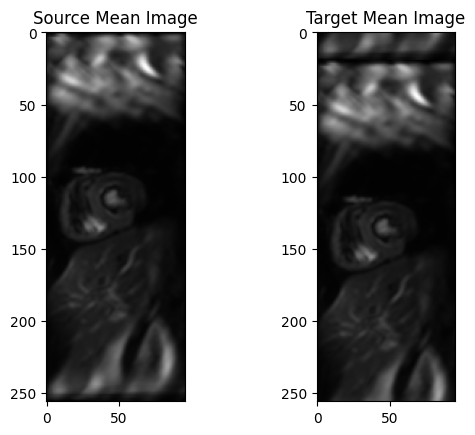

In [25]:
# plot the two mean images
plt.subplot(1, 2, 1)
plt.imshow(source_toseg_mean, cmap='gray')
plt.title('Source Mean Image')
plt.subplot(1, 2, 2)
plt.imshow(target_toseg_mean, cmap='gray')
plt.title('Target Mean Image')

In [26]:
# create mask stack of the FOV central region

image_stack = source_reged_img_stack
mask = np.zeros([image_stack.shape[-2], image_stack.shape[-1]])
if image_stack.shape[-2] > image_stack.shape[-1]:
    short_dim = image_stack.shape[-1]
    large_dim = image_stack.shape[-2]
    mask[int((large_dim - short_dim * 1.2) / 2) : int((large_dim + short_dim * 1.2) / 2), :] = 1
else:
    short_dim = image_stack.shape[-2]
    large_dim = image_stack.shape[-1]
    mask[:, int((large_dim - short_dim * 1.2) / 2) : int((large_dim + short_dim * 1.2) / 2)] = 1

mask = (mask > 0).astype(np.uint8) 
fixed_mask_arr = np.asarray(mask, dtype=np.ubyte)

image_stack = target_reged_img_stack
mask = np.zeros([image_stack.shape[-2], image_stack.shape[-1]])
if image_stack.shape[-2] > image_stack.shape[-1]:
    short_dim = image_stack.shape[-1]
    large_dim = image_stack.shape[-2]
    mask[int((large_dim - short_dim * 1.2) / 2) : int((large_dim + short_dim * 1.2) / 2), :] = 1
else:
    short_dim = image_stack.shape[-2]
    large_dim = image_stack.shape[-1]
    mask[:, int((large_dim - short_dim * 1.2) / 2) : int((large_dim + short_dim * 1.2) / 2)] = 1
mask = (mask > 0).astype(np.uint8) 
moved_mask_arr = np.asarray(mask, dtype=np.ubyte)


In [27]:
# redo the registration
parameter_object = itk.ParameterObject.New()
parameter_object.AddParameterFile(
    os.path.join('/Users/wangfanwen/Projects/INDI_latest/src/indi/', "extensions", "image_registration_recipes", "Elastix_rigid.txt")
)

# parameter_object.SetParameter("MaximumNumberOfIterations", "2000")
# parameter_object.SetParameter("NumberOfResolutions", "4")

In [28]:
source_mean_itk = itk.GetImageFromArray(source_toseg_mean)
target_mean_itk = itk.GetImageFromArray(target_toseg_mean)
fixed_mask_itk = itk.GetImageFromArray(fixed_mask_arr)
moved_mask_itk = itk.GetImageFromArray(moved_mask_arr)

In [29]:
img_reg, result_transform_parameters = itk.elastix_registration_method(
    target_mean_itk,
    source_mean_itk,
    parameter_object=parameter_object,
    fixed_mask = fixed_mask_itk,
    log_to_console=False,
)
img_reg_arr = itk.GetArrayFromImage(img_reg)

grid_img = get_grid_image(source_toseg_mean.shape, 10)
grid_img_itk = itk.GetImageFromArray(grid_img)
grid_img_transformed = itk.transformix_filter(grid_img_itk, result_transform_parameters)
grid_img_transformed_np = itk.GetArrayFromImage(grid_img_transformed)
grid_img_transformed_np[grid_img_transformed_np < 0.1] = 0
grid_img_transformed_np[grid_img_transformed_np >= 0.1] = 0.6

In [30]:
def_field = itk.transformix_deformation_field(target_mean_itk, result_transform_parameters)
def_field_np = np.asarray(def_field).astype(np.float32)

binary_parameters = result_transform_parameters
binary_parameters.SetParameter(0, "ResampleInterpolator", ["FinalNearestNeighborInterpolator"])
binary_parameters.SetParameter(0, "FinalBSplineInterpolationOrder", ["0"])

mask_3c_itk = itk.GetImageFromArray(mask_3c)
mask_itk_new = itk.transformix_filter(mask_3c_itk, binary_parameters)
mask_3c_new = itk.GetArrayFromImage(mask_itk_new)
# transfer the points
epicardium_new = transfer_points(epicardium, def_field_np)
endocardium_new = transfer_points(endocardium, def_field_np)
anterior_ip_old = anterior_ip[np.newaxis, :]
anterior_ip_new = transfer_points(anterior_ip_old, def_field_np)
inferior_ip_old = inferior_ip[np.newaxis, :]
inferior_ip_new = transfer_points(inferior_ip_old, def_field_np)
# get the disp from the 
inferior_ip_new = inferior_ip_new[0]
anterior_ip_new = anterior_ip_new[0]

Text(0.5, 1.0, 'Disp')

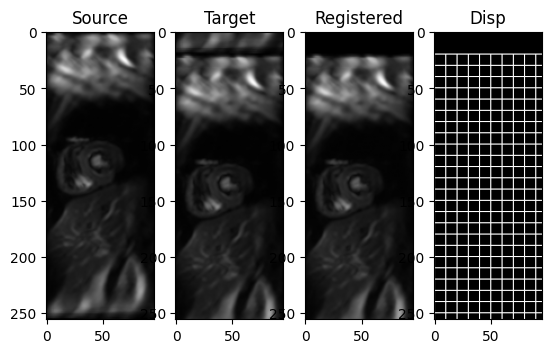

In [31]:
# plot the registered mean image
plt.subplot(1, 4, 1)
plt.imshow(source_toseg_mean, cmap='gray')
plt.title('Source')
plt.subplot(1, 4, 2)
plt.imshow(target_toseg_mean, cmap='gray')
plt.title('Target')
plt.subplot(1, 4, 3)
plt.imshow(img_reg_arr, cmap='gray')
plt.title('Registered')
plt.subplot(1, 4, 4)
plt.imshow(grid_img_transformed_np, cmap='gray')
plt.title('Disp')

Text(0.5, 1.0, 'Moved')

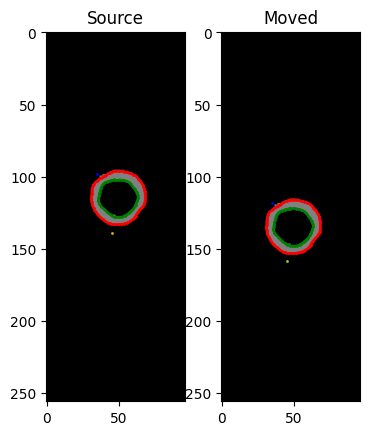

In [32]:
# plot the registered mean image\
ms = 2          # marker size in points – shrink or grow as you like

plt.subplot(1, 3, 1)
plt.imshow(mask_3c, cmap='gray')
plt.plot(epicardium[:, 0], epicardium[:, 1], color='r', linestyle='-', marker='.', markersize=ms)
plt.plot(endocardium[:, 0], endocardium[:, 1], color='g', linestyle='-', marker='.', markersize=ms)
plt.plot(anterior_ip[0],  anterior_ip[1],  color='b', linestyle='-', marker='.', markersize=ms)
plt.plot(inferior_ip[0],  inferior_ip[1],  color='y', linestyle='-', marker='.', markersize=ms)
plt.title('Source')

plt.subplot(1, 3, 2)
plt.imshow(mask_3c_new, cmap='gray')
plt.plot(epicardium_new[:, 0], epicardium_new[:, 1], color='r', linestyle='-', marker='.', markersize=ms)
plt.plot(endocardium_new[:, 0], endocardium_new[:, 1], color='g', linestyle='-', marker='.', markersize=ms)
plt.plot(anterior_ip_new[0],  anterior_ip_new[1],  color='b', linestyle='-', marker='.', markersize=ms)
plt.plot(inferior_ip_new[0],  inferior_ip_new[1],  color='y', linestyle='-', marker='.', markersize=ms)
plt.title("Moved")

In [ ]:
# save the seges to the target directory


np.savez_compressed(
    os.path.join(target_session_dir, "manual_lv_segmentation_slice_" + str(slice_idx).zfill(3) + ".npz"),
    mask_3c=mask_3c_new,
    segmentation=segmentation_new,
)